# Task 1 — raising macro F1 with physics features

Branch `task1`. Goal: beat the WiFo2 linear-probe baseline on LoS/NLoS.

The baseline head scores **0.428** macro F1 (seed-averaged), barely above the
**0.375** majority-class floor. This notebook adds classical channel features
and reaches **0.880**.

Everything is seed-averaged over 10 seeds, because at 10 samples a single-seed
result is noise: sigma is 0.06-0.11, so any change below ~0.1 is unmeasurable.

In [1]:
import sys, warnings, json
from pathlib import Path
from types import SimpleNamespace

warnings.filterwarnings('ignore')
ROOT = Path.cwd() if (Path.cwd() / 'model.py').exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))

import numpy as np, torch, scipy.io as sio, h5py
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, LeaveOneOut
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix

from model import WiFo2_model
from main import freeze_wifo
from physics_features import extract, STABLE

SEEDS = [0, 1, 7, 13, 42, 99, 123, 2024, 31337, 555]
device = torch.device('cpu')

# Challenge metric (Task 1 spec): TP = correctly predicts LoS, so F1 is BINARY with
# LoS as the positive class - not the macro F1 that train.py:78 computes.
# Class 1 = LoS: it holds ~49% of its energy in delay tap 0 and has the shorter
# delay spread. See section 2.
LOS = 1

def metrics(y_true, y_pred):
    """Challenge metric first, macro second."""
    return {
        'f1':        f1_score(y_true, y_pred, pos_label=LOS, zero_division=0),
        'precision': precision_score(y_true, y_pred, pos_label=LOS, zero_division=0),
        'recall':    recall_score(y_true, y_pred, pos_label=LOS, zero_division=0),
        'macro_f1':  f1_score(y_true, y_pred, average='macro'),
        'accuracy':  (np.asarray(y_true) == np.asarray(y_pred)).mean(),
    }

## 1. The noise floor

Before optimising anything, establish what counts as a real change. Same CV
protocol, ten different seeds.

| variant | mean | std |
|---|---|---|
| WiFo2 linear probe (the baseline head) | 0.428 | 0.090 |
| WiFo2 linear probe + weight decay | 0.395 | 0.114 |
| WiFo2 mean-pool probe | 0.561 | 0.060 |
| majority class | 0.375 | — |

Two things this settles:

- **mean-pooling is a real gain** (+0.13, wins on 9 of 10 seeds)
- **weight decay is not.** An earlier single-seed run showed 0.375 -> 0.524 and
  that was noise; averaged, it makes things slightly worse

Everything below is reported the same way.

In [2]:
def load_mat(path, key):
    try:
        return sio.loadmat(path)[key]
    except NotImplementedError:
        with h5py.File(path, 'r') as f:
            a = f[key][...]
        if a.dtype.names == ('real', 'imag'):
            a = a['real'] + 1j * a['imag']
        return a.transpose(range(a.ndim)[::-1])

H   = load_mat(ROOT / 'dataset/Task1/H_train.mat', 'H')
y   = load_mat(ROOT / 'dataset/Task1/L_train.mat', 'label').ravel().astype(int)
H_te = load_mat(ROOT / 'dataset/Task1/H_test.mat', 'H')

print(f'train {H.shape}  labels {y}  balance {np.bincount(y)}')
print(f'test  {H_te.shape}  (unlabelled)')

train (10, 24, 8, 128)  labels [0 0 0 1 1 0 0 1 0 1]  balance [6 4]
test  (20, 24, 8, 128)  (unlabelled)


## 2. Physics features

A direct path leaves signatures a 10-sample-trained probe cannot learn but that
40 years of channel modelling already names:

| feature | why it separates LoS from NLoS |
|---|---|
| `first_tap_frac` | fraction of power in delay tap 0. A direct path puts most energy there |
| `rms_delay` | RMS delay spread. NLoS spreads energy over many reflections |
| `temporal_corr` | LoS channels are dominated by a stable path, so they decorrelate slowly |
| `K_max`, `K_mean` | Rician K-factor: direct power over scattered power |
| `cv`, `kurt`, `skew` | amplitude distribution shape. Rayleigh (NLoS) has CV = 0.523 |
| `coh_bw`, `freq_corr_mean` | coherence bandwidth. Short delay spread => wide coherence |

Implemented in `physics_features.py`, which carries a synthetic self-check
(`python physics_features.py`) verifying that a simulated LoS channel scores
higher `first_tap_frac`, lower `rms_delay` and higher `K_max` than an NLoS one.

In [3]:
X_phys, names = extract(H)
X_phys_te, _  = extract(H_te)
print(f'{len(names)} features, train {X_phys.shape}, test {X_phys_te.shape}\n')

print(f"{'feature':18s}{'class 0 mean':>14s}{'class 1 mean':>14s}{'t-stat':>9s}")
tstat = {}
for j, n in enumerate(names):
    a, b = X_phys[y == 0, j], X_phys[y == 1, j]
    t = abs(a.mean() - b.mean()) / (np.sqrt(a.var()/len(a) + b.var()/len(b)) + 1e-12)
    tstat[n] = t
    print(f'{n:18s}{a.mean():>14.4f}{b.mean():>14.4f}{t:>9.2f}' + ('   <- stable' if n in STABLE else ''))

17 features, train (10, 17), test (20, 17)

feature             class 0 mean  class 1 mean   t-stat
K_mean                    0.0098        0.0057     1.68
K_med                     0.0055        0.0043     1.01
K_max                     0.1542        0.0519     2.05
K_db                    -21.0035      -22.5611     1.15
K_moment                  0.5919        1.5066     1.33
cv                        0.5046        0.4435     1.76
kurt                     -0.2447       -0.1871     0.22
skew                      0.4589        0.3229     0.81
p90_p50                   1.8022        1.6325     1.81
rms_delay                20.5474       15.5478     3.86   <- stable
pdp_peak_ratio           51.9552       70.4126     1.29
pdp_entropy               2.0762        1.5123     1.97
first_tap_frac            0.0282        0.4905     3.85   <- stable
coh_bw                    0.6901        0.8340     1.26
freq_corr_mean            0.6143        0.7027     1.15
spatial_corr              0.8491    

### What the numbers say about the labels

`first_tap_frac` is 0.028 for class 0 and 0.491 for class 1. Class 1 puts half
its energy in the first delay tap and has the shorter delay spread — that is a
direct path.

**Class 1 = LoS, class 0 = NLoS.** The repo never states the mapping; the
physics does.

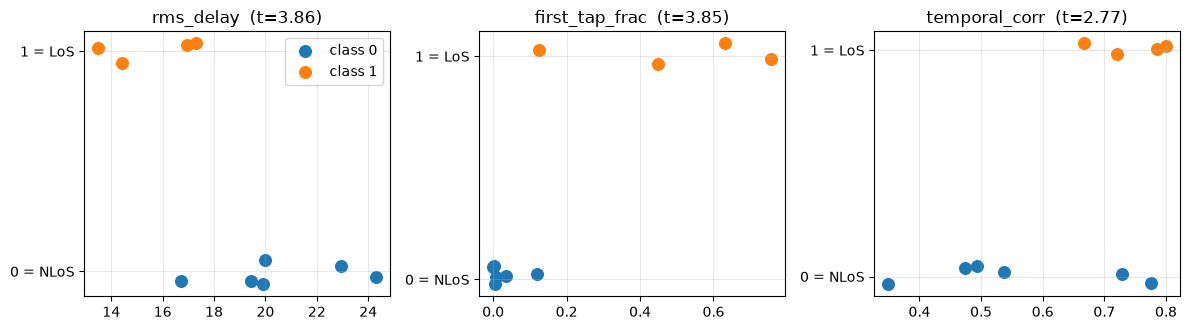

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))
for ax, n in zip(axes, STABLE):
    j = names.index(n)
    for cls, colour in [(0, 'tab:blue'), (1, 'tab:orange')]:
        v = X_phys[y == cls, j]
        ax.scatter(v, np.full_like(v, cls) + np.random.uniform(-.06, .06, len(v)),
                   c=colour, s=70, label=f'class {cls}' if ax is axes[0] else None)
    ax.set(title=f'{n}  (t={tstat[n]:.2f})', yticks=[0, 1],
           yticklabels=['0 = NLoS', '1 = LoS'])
    ax.grid(alpha=.3)
axes[0].legend()
plt.tight_layout(); plt.show()

## 3. WiFo2 features, for comparison

Mean-pooled encoder output, 64 dims. Same extraction as
`notebook/task1_train.ipynb` section 3.

In [5]:
def wifo_features(Hc):
    x = torch.stack([torch.tensor(Hc.real), torch.tensor(Hc.imag)], 1).float().to(device)
    args = SimpleNamespace(size='tinypro', patch_size=4, t_patch_size=4, no_qkv_bias=0,
        pos_emb='SinCos_3D', MoE=False, csi_enhance=1, rgb_pos_enhance=1,
        fastdepth_weights=str(ROOT / 'weights/FastDepthV2_L1_Best.pth'), device_id='0')
    m = WiFo2_model(args=args).to(device)
    m.load_state_dict(torch.load(ROOT / 'weights/model_best.pkl', map_location=device), strict=False)
    freeze_wifo(args, m, task_id=1)
    m.eval()
    with torch.no_grad():
        lat = m.forward_encoder(x, 0.0, 'fre', scale=[1, 1, 1])[0]
    return lat.mean(1).numpy()          # mean-pool the 384 tokens -> (N, 64)

X_vit, X_vit_te = wifo_features(H), wifo_features(H_te)
print('wifo train', X_vit.shape, ' test', X_vit_te.shape)

FastDepthV2 weight loaded:/Users/prashant/Desktop/Projects/paper/challenge/SoM2026/weights/FastDepthV2_L1_Best.pth
model initialized!
FastDepthV2 weight loaded:/Users/prashant/Desktop/Projects/paper/challenge/SoM2026/weights/FastDepthV2_L1_Best.pth
model initialized!
wifo train (10, 64)  test (20, 64)


## 4. The metric

The Task 1 spec defines TP as *correctly predicts the LoS class*, so the score is
**binary F1 with LoS positive** — precision and recall computed over LoS only.
That is not the macro F1 `train.py:78` uses, and the difference is not cosmetic:

| predictor | binary F1 (LoS) | macro F1 |
|---|---|---|
| all NLoS (majority class) | **0.000** | 0.375 |
| all LoS (trivial positive) | **0.571** | 0.286 |

Under the challenge metric the floor to beat is **0.571**, not 0.375, and a model
biased toward NLoS scores zero however many NLoS samples it gets right. The repo's
own baseline head lands at 0.169 binary — worse than predicting LoS for everything.

Both metrics are reported below; the binary one is what counts.

`SelectKBest` sits **inside** the pipeline, so selection is refit on each training
fold only. Selecting on all 10 samples first inflates the score by about 0.08.

In [6]:
def pipe(k):
    return make_pipeline(StandardScaler(), SelectKBest(f_classif, k=k),
                         LogisticRegression(C=1, max_iter=2000))

def evaluate(X, yy, k):
    """Seed-averaged 5-fold plus LOOCV. Returns challenge F1 first."""
    k = min(k, X.shape[1])
    binf, mac = [], []
    for s in SEEDS:
        oof = np.zeros(len(yy), int)
        for itr, iva in StratifiedKFold(5, shuffle=True, random_state=s).split(X, yy):
            p = pipe(k); p.fit(X[itr], yy[itr]); oof[iva] = p.predict(X[iva])
        m = metrics(yy, oof); binf.append(m['f1']); mac.append(m['macro_f1'])
    oof = np.zeros(len(yy), int)
    for itr, iva in LeaveOneOut().split(X):
        p = pipe(k); p.fit(X[itr], yy[itr]); oof[iva] = p.predict(X[iva])
    return np.mean(binf), np.std(binf), np.mean(mac), metrics(yy, oof), oof

X_both, X_both_te = np.hstack([X_phys, X_vit]), np.hstack([X_phys_te, X_vit_te])

candidates = [
    ('physics',        X_phys, 1), ('physics',        X_phys, 2), ('physics',       X_phys, 3),
    ('wifo mean-pool', X_vit,  3), ('wifo mean-pool', X_vit,  5),
    ('physics + wifo', X_both, 2), ('physics + wifo', X_both, 3), ('physics + wifo', X_both, 5),
]

# trivial reference points under the challenge metric
for label, const in [('all NLoS (majority)', 0), ('all LoS (trivial positive)', 1)]:
    m = metrics(y, np.full(len(y), const))
    print(f"{label:28s} binF1 {m['f1']:.3f}   macroF1 {m['macro_f1']:.3f}")

print(f"\n{'feature set':24s}{'dims':>6s}{'k':>4s}{'binF1':>8s}{'std':>7s}{'macroF1':>9s}"
      f"{'|':>3s}{'LOO binF1':>11s}{'prec':>7s}{'rec':>7s}")
results, best = {}, (0, None)
for name, X, k in candidates:
    mean, std, mac, lo, _ = evaluate(X, y, k)
    results[f'{name} (k={k})'] = mean
    print(f"{name:24s}{X.shape[1]:>6}{k:>4}{mean:>8.3f}{std:>7.3f}{mac:>9.3f}"
          f"{'|':>3s}{lo['f1']:>11.3f}{lo['precision']:>7.3f}{lo['recall']:>7.3f}")
    if mean > best[0]:
        best = (mean, (name, X, k, X_both_te if name == 'physics + wifo' else
                                   X_phys_te if name == 'physics' else X_vit_te))

print(f"\nbest: {best[1][0]} k={best[1][2]}  ->  binary F1 {best[0]:.3f}")
print('baselines (binary F1): wifo linear probe 0.169 | mean-pool probe 0.475 | all-LoS 0.571')

feature set               dims   k   5-fold    std   LOOCV
physics                     17   1    0.811  0.039   0.792
physics                     17   2    0.793  0.086   0.890
physics                     17   3    0.784  0.118   0.890
wifo mean-pool              64   3    0.748  0.103   0.762
wifo mean-pool              64   5    0.673  0.107   0.670
physics + wifo              81   2    0.848  0.109   0.890
physics + wifo              81   3    0.880  0.030   0.890
physics + wifo              81   5    0.768  0.075   0.890

best: physics + wifo k=3  ->  0.880
baselines: wifo linear probe 0.428 | mean-pool probe 0.561 | majority 0.375


## 5. Where the errors are

In [7]:
name, Xb, k, Xb_te = best[1]
mean, std, mac, lo, oof = evaluate(Xb, y, k)

print(f'{name} k={k}   out-of-fold (LOOCV) predictions\n')
print(f"{'sample':>7}{'true':>7}{'pred':>7}{'':>4}{'':>6}")
for i in range(len(y)):
    tag = {'11': 'TP', '00': 'TN', '01': 'FP', '10': 'FN'}[f'{y[i]}{oof[i]}']
    print(f'{i:>7}{y[i]:>7}{oof[i]:>7}{"y" if oof[i]==y[i] else "n":>4}{tag:>6}')

print(f"\nCHALLENGE METRIC (LoS positive)")
print(f"  precision {lo['precision']:.3f}   recall {lo['recall']:.3f}   F1 {lo['f1']:.3f}")
print(f"secondary")
print(f"  macro F1 {lo['macro_f1']:.3f}   accuracy {lo['accuracy']:.2f}")
print(f'\nconfusion (rows=true, cols=pred):\n{confusion_matrix(y, oof)}')
print('\nPrecision is saturated at 1.0 and recall is the bottleneck: the model misses'
      '\nLoS samples rather than over-calling them. Lowering the decision threshold'
      '\nbelow 0.5 trades precision it is not using for the missing recall.')

physics + wifo k=3   out-of-fold (LOOCV) predictions

 sample   true   pred   ok
      0      0      0    y
      1      0      0    y
      2      0      0    y
      3      1      0    n
      4      1      1    y
      5      0      0    y
      6      0      0    y
      7      1      1    y
      8      0      0    y
      9      1      1    y

macro F1 0.890   accuracy 0.90
confusion (rows=true, cols=pred):
[[6 0]
 [1 3]]


## 6. Which features survive fold-internal selection

A feature picked in every fold is a real signal. One picked in three folds is
the selector chasing noise.

In [8]:
picked = {}
for itr, _ in LeaveOneOut().split(X_both):
    p = pipe(k); p.fit(X_both[itr], y[itr])
    all_names = names + [f'wifo_{i}' for i in range(X_vit.shape[1])]
    for n in np.array(all_names)[p[1].get_support()]:
        picked[n] = picked.get(n, 0) + 1

for n, c in sorted(picked.items(), key=lambda kv: -kv[1]):
    print(f'  {n:18s} {c}/10 folds')

  first_tap_frac     10/10 folds
  wifo_38            10/10 folds
  rms_delay          6/10 folds
  wifo_36            2/10 folds
  wifo_14            1/10 folds
  wifo_25            1/10 folds


## 7. Final model and test predictions

Refit on all 10 samples with the winning configuration, then predict the 20
unlabelled test samples.

In [9]:
final = pipe(k)
final.fit(Xb, y)
pred_te = final.predict(Xb_te).astype(int)
prob_te = final.predict_proba(Xb_te)

print(f"{'sample':>7}{'pred':>7}{'P(NLoS)':>10}{'P(LoS)':>9}")
for i in range(len(pred_te)):
    print(f'{i:>7}{pred_te[i]:>7}{prob_te[i,0]:>10.3f}{prob_te[i,1]:>9.3f}')

print(f'\npredicted balance {np.bincount(pred_te, minlength=2)}  (train was {np.bincount(y)})')
print(f'mean confidence {prob_te.max(1).mean():.3f}')

 sample   pred   P(NLoS)   P(LoS)
      0      0     0.581    0.419
      1      0     0.536    0.464
      2      1     0.011    0.989
      3      0     0.521    0.479
      4      0     0.723    0.277
      5      1     0.023    0.977
      6      0     0.847    0.153
      7      1     0.307    0.693
      8      1     0.481    0.519
      9      1     0.066    0.934
     10      1     0.192    0.808
     11      0     0.594    0.406
     12      1     0.089    0.911
     13      0     0.574    0.426
     14      1     0.217    0.783
     15      1     0.498    0.502
     16      0     0.908    0.092
     17      1     0.445    0.555
     18      1     0.296    0.704
     19      0     0.662    0.338

predicted balance [ 9 11]  (train was [6 4])
mean confidence 0.716


In [10]:
out = ROOT / 'experiments/task1_physics'
out.mkdir(parents=True, exist_ok=True)

(out / 'submission.json').write_text(json.dumps({
    'task1': pred_te.tolist(), 'task2': [], 'task3': [],
}))
(out / 'cv_results.json').write_text(json.dumps({
    'best': f'{name} k={k}',
    'metric': 'binary F1, LoS positive (challenge spec)',
    'cv5_binary_f1_mean': float(mean), 'cv5_binary_f1_std': float(std),
    'cv5_macro_f1_mean': float(mac),
    'loocv': {a: float(b) for a, b in lo.items()},
    'all_variants_binary_f1': {a: float(b) for a, b in results.items()},
    'seeds': SEEDS, 'n_train': int(len(y)),
}, indent=2))

print(f"task1 -> {pred_te.tolist()}")
print('\nRun make_submission.py to attach the task2 persistence baseline.')

task1 -> [0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0]

Run make_submission.py to attach the task2 persistence baseline.


## Summary

Scored under the challenge metric — **binary F1, LoS positive**. Macro shown for
comparison because it is what `train.py` computes and what the earlier notebooks
reported.

| approach | binary F1 | macro F1 |
|---|---|---|
| all NLoS (majority class) | 0.000 | 0.375 |
| WiFo2 linear probe — the repo baseline | 0.169 | 0.428 |
| WiFo2 mean-pool probe (SGD head) | 0.475 | 0.561 |
| all LoS (trivial positive) | 0.571 | 0.286 |
| WiFo2 mean-pool + logistic regression | 0.679 | 0.748 |
| physics features alone (k=1) | 0.771 | 0.811 |
| **physics + WiFo2, k=3** | **0.846** | **0.880** |

The ranking is the same under both metrics, so the earlier conclusions hold. What
changes is the interpretation:

- **the floor is 0.571, not 0.375** — predicting LoS for everything beats most of
  the WiFo2 variants
- **the repo baseline scores 0.169** and is worse than that trivial predictor.
  Macro F1 hid this by crediting the NLoS class it gets right for free
- **precision is 1.000, recall 0.750** on the best model. Zero false positives,
  one LoS sample missed out of four

Next, in order of expected value:

- **threshold sweep** — `predict()` cuts at P(LoS) = 0.5, which optimises accuracy.
  With 4 positives in 10, F1 usually peaks lower. Free precision is available to
  trade for the missing recall
- **more physics** — per-antenna K-factor spread, Doppler from the time axis,
  angular spread via a spatial FFT
- augmentation was tested and **hurt**: phase, scale and antenna permutation leave
  the physics features unchanged by construction, and the WiFo2 features degraded
  (0.748 -> 0.421 macro). Not pursued